<a href="https://colab.research.google.com/github/gui-o-correa/pratica-git/blob/main/D2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ♻️ MISSÃO RECOMEÇO
### Desafio 2 · Trilha de Visão Computacional · Olimpíada de IA Aplicada 2026

---

> **"Eu separo material há vinte e dois anos. Sei distinguir os cinco tipos pelo brilho,
> antes mesmo de tocar. A pergunta é se isso que eu sei pode ser descrito com precisão
> suficiente para uma máquina reproduzir."**
>
> — Rosa Bezerra, presidente da Cooperativa Recomeço

---

<img src="https://lh3.googleusercontent.com/d/1Qz9zzwL-EcWPeVBi5_Gz0tc5pOyGoSvm=w1600" width="100%"
     alt="Galpão de cooperativa de reciclagem: Rosa, de lenço colorido no cabelo e luvas verdes, sorri à beira da esteira. Uma câmera sobre tripé, com luz ciano, aponta para as embalagens que passam. Ao fundo, fardos e montanhas de material separado.">


## 📨 O chamado da Cooperativa Recomeço

*A sua equipe recebe um convite para visitar um galpão na periferia da cidade.
Vocês aceitam. E o que encontram lá muda a forma como vocês olham para o lixo.*

---

**De:** Cooperativa Recomeço · Setor de Triagem
**Para:** Equipe de Engenharia de Visão Computacional

> Presido uma cooperativa com 34 associados. Recebemos cerca de seis toneladas diárias de
> material misto, separadas manualmente peça por peça.
>
> O problema é econômico e mensurável. Lotes com contaminação, por exemplo vidro
> particulado misturado ao papel, são desclassificados na venda e reduzem drasticamente a
> receita do mês. A taxa de erro na triagem manual cresce ao longo do turno, por fadiga.
>
> Fomos procurados por um grupo da universidade que sugeriu classificação automática por
> imagem. Não domino a técnica, mas domino o material, e talvez seja aí que eu possa
> contribuir com vocês.
>
> **Cada material tem uma assinatura óptica distinta.** O papel é fosco, de reflexão
> difusa. O papelão também é fosco, mas é mais escuro e tem textura de ondulação. O
> plástico tem cor saturada e superfície regular. O vidro é parcialmente translúcido e
> produz reflexos concentrados. O metal tem reflexão especular intensa, quase sempre em
> faixas.
>
> Reparem que eu acabei de descrever, com as palavras que tenho, propriedades que são
> mensuráveis. Suspeito que seja exatamente isso que vocês precisam extrair.
>
> Instalamos uma câmera sobre a esteira e registramos alguns milhares de imagens,
> rotuladas por tipo. **Aviso que as condições não são de laboratório:** a iluminação do
> galpão varia ao longo do dia e o material chega sujo. É o dado real que temos.
>
> Duas advertências. **Papel e papelão são a dupla que mais confunde**, inclusive gente
> experiente. E os cinco tipos não chegam em quantidades iguais: entra bem mais papel do
> que papelão, e isso é a nossa rotina, não um defeito da amostra.
>
> — Rosa Bezerra

---

*As observações finais da mensagem não são detalhes. Elas definem a dificuldade do problema.*


## 🎯 A sua missão

Construir um modelo de IA que **olha uma foto de um material** e diz se é
**papel**, **papelão**, **plástico**, **vidro** ou **metal**.

### O problema da representação

Uma imagem digital é uma matriz de intensidades: cada pixel guarda três valores, um por
canal de cor. Uma imagem de 48 por 48 pixels contém, portanto, 6.912 valores. Entregar essa
matriz bruta a um classificador clássico é inviável por dois motivos: a dimensionalidade é
alta demais em relação ao número de exemplos disponíveis, e a representação por pixel é
frágil, já que qualquer deslocamento do objeto altera completamente o vetor.

A alternativa clássica, e a que este desafio adota, é a **extração de características**:
substituir os milhares de valores brutos por um conjunto pequeno de medidas que descrevem
propriedades globais da imagem, como brilho médio, contraste, saturação, densidade de
bordas e proporção de área com alta luminância.

Reparem no que a Rosa fez na mensagem. Ao descrever reflexão difusa, saturação e reflexo
especular, ela enunciou, em linguagem natural, um conjunto de descritores. **Conhecimento
de domínio é o que orienta a escolha das características**, e é por isso que projetos de IA
aplicada dão errado quando a equipe técnica não conversa com quem entende do problema.

> Consequência prática: depois da extração, cada imagem passa a ser uma linha de uma
> tabela, e o problema se reduz a uma classificação tabular convencional. Os mesmos
> algoritmos e a mesma interface do desafio anterior voltam a valer.

### 🗺️ O mapa da missão

| Bloco | O que vocês fazem | Como |
|:---|:---|:---|
| **1 · EXPLORAR** | Ver as fotos da esteira e descobrir o que separa cada material | Só clicando |
| **2 · CONFIGURAR** | Decidir quais características usar e como treinar | Só arrastando |
| **3 · MODELAR** | Ensinar o modelo a enxergar | ✏️ Completando o código |
| **4 · AVALIAR** | Descobrir onde o modelo se confunde, e por quê | Só clicando |

> ⚠️ Confirme que o ambiente está em **CPU** (`Ambiente de execução` → `Alterar o tipo`).
> Não usamos rede neural pesada aqui: nosso modelo roda em **segundos**, e mesmo assim
> aprende muito bem. Inteligência não é sinônimo de peso.


In [ ]:
#@title 🛠️ Preparação: recebendo as fotos da esteira { display-mode: "form" }
# Endereços oficiais dos dados. A organização republica aqui se precisar trocar.
URL_TREINO_FOTOS = "https://drive.google.com/uc?export=download&id=1lJRXzTupXGUrn3R6tdnA7ulROYEEe7RX"
URL_TESTE_FOTOS = "https://drive.google.com/uc?export=download&id=10gpTF72qwQ7a15Q-ZruntCnlB59RPSGD"

import pathlib, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

CLASSES = ["papel", "papelao", "plastico", "vidro", "metal"]
EMOJI   = {"papel":"📄", "papelao":"📦", "plastico":"🧴", "vidro":"🍾", "metal":"🥫"}


def extrair_caracteristicas(fotos):
    """👀 Transforma cada FOTO em uma LINHA DE NÚMEROS que o modelo entende."""
    L = []
    for im in fotos:
        cinza = im.mean(axis=2)
        gx = np.abs(np.diff(cinza, axis=1)).mean()
        gy = np.abs(np.diff(cinza, axis=0)).mean()
        mx, mn = im.max(axis=2), im.min(axis=2)
        satur  = np.where(mx > 0, (mx - mn) / (mx + 1e-6), 0)
        L.append([im[...,0].mean(), im[...,1].mean(), im[...,2].mean(),
                  im[...,0].std(),  im[...,1].std(),  im[...,2].std(),
                  cinza.mean(), cinza.std(), np.percentile(cinza, 95),
                  np.percentile(cinza, 95) - np.percentile(cinza, 5),
                  (gx + gy) / 2, satur.mean(), satur.std(),
                  (cinza > .80).mean()])
    return pd.DataFrame(L, columns=[
        "vermelho_medio","verde_medio","azul_medio",
        "vermelho_variacao","verde_variacao","azul_variacao",
        "brilho_medio","contraste","brilho_alto",
        "amplitude_luz","bordas","saturacao_media","saturacao_variacao","area_reluzente"])


def _npz(url, nome_local):
    """Baixa do endereço oficial; sem endereço ou sem rede, pede o envio."""
    if url and not pathlib.Path(nome_local).exists():
        import urllib.request
        try:
            print(f"Baixando {nome_local}...")
            urllib.request.urlretrieve(url, nome_local)
        except Exception as erro:
            print(f"  não deu certo ({erro.__class__.__name__}).")
    if not pathlib.Path(nome_local).exists():
        from google.colab import files
        print(f"Envie o arquivo {nome_local}:")
        files.upload()
    return np.load(nome_local, allow_pickle=False)


# As fotos vêm em uint8 (0-255), como qualquer imagem; o modelo trabalha em [0,1].
_treino = _npz(URL_TREINO_FOTOS, "treino_fotos.npz")
_teste = _npz(URL_TESTE_FOTOS, "teste_fotos.npz")

# Conjunto PÚBLICO: rotulado. Serve para treinar e validar.
fotos = _treino["fotos"].astype(np.float32) / 255.0
rotulos = _treino["rotulos"]

# Conjunto de TESTE: tamanho fixo, rótulos ocultos. Base da comparação oficial.
fotos_teste = _teste["fotos"].astype(np.float32) / 255.0
N_TESTE = len(fotos_teste)

print("Ambiente carregado.")
print(f"  Conjunto público (rotulado) ....... {len(fotos):>4} imagens, {len(CLASSES)} materiais")
print(f"  Conjunto de teste (sem rótulo) .... {len(fotos_teste):>4} imagens  [tamanho fixo]")
print(f"  Cada imagem: {fotos.shape[1]}x{fotos.shape[2]} pixels x 3 canais = "
      f"{fotos.shape[1]*fotos.shape[2]*3:,} valores")
print(f"\n  A submissão precisará ter exatamente {N_TESTE} linhas.")
print("\n   A etapa seguinte reduz essa representação a um conjunto pequeno")
print("   de descritores com poder discriminante.")

Ambiente carregado.
  Conjunto público (rotulado) ....... 2150 imagens, 5 materiais
  Conjunto de teste (sem rótulo) ....  240 imagens  [tamanho fixo]
  Cada imagem: 48x48 pixels x 3 canais = 6,912 valores

  A submissão precisará ter exatamente 240 linhas.

   A etapa seguinte reduz essa representação a um conjunto pequeno
   de descritores com poder discriminante.


---
# 🔍 BLOCO 1 · EXPLORAR
## *Olhem com os olhos da Dona Rosa*

> **Rosa:** *"Antes de programar qualquer coisa, olhem o material. Vocês precisam
> conseguir descrever a diferença antes de tentar medi-la."*

Cada propriedade que vocês conseguirem verbalizar nesta etapa corresponde a um descritor
que pode ser calculado. A qualidade da representação depende dessa observação inicial.


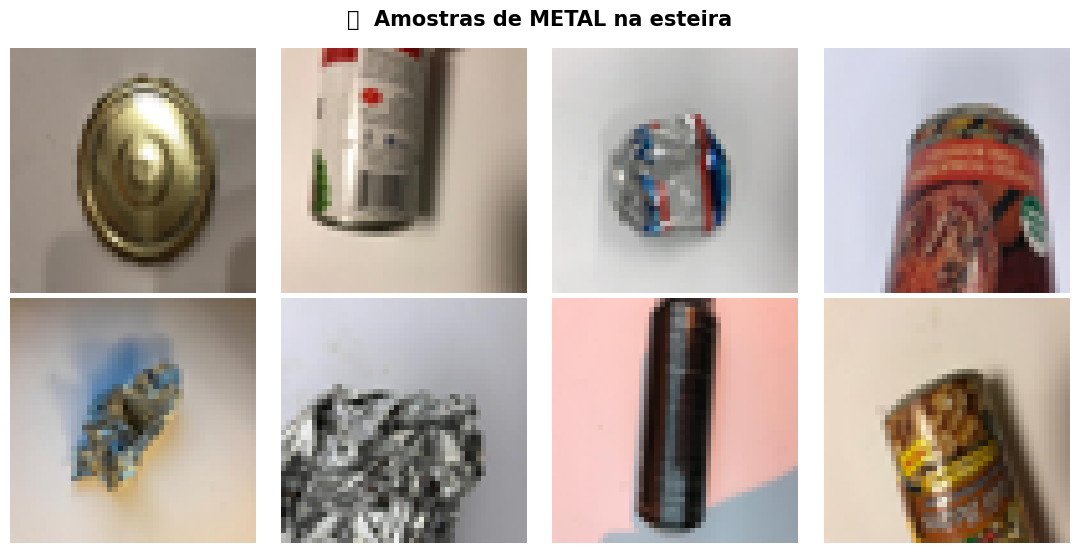

Analisem as amostras de METAL sob quatro dimensões:
   Luminância    - a superfície é clara ou escura, e quão uniforme é?
   Saturação     - a cor é intensa ou próxima do acromático?
   Reflectância  - a reflexão é difusa (espalhada) ou especular (concentrada)?
   Textura       - há variação local de intensidade ou a superfície é homogênea?

Alternem entre os materiais e registrem quais dimensões os separam melhor.
Essa análise antecipa quais descritores terão poder discriminante.


In [ ]:
#@title 📷 As fotos da esteira { display-mode: "form" }
#@markdown Escolha um material e rode a célula (▶) para ver oito fotos dele.
material = "metal"  #@param ["papel", "papelao", "plastico", "vidro", "metal"]

idx = np.where(rotulos == material)[0][:8]
fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(fotos[i]); ax.axis("off")
fig.suptitle(f"{EMOJI[material]}  Amostras de {material.upper()} na esteira",
             fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Analisem as amostras de {material.upper()} sob quatro dimensões:")
print("   Luminância    - a superfície é clara ou escura, e quão uniforme é?")
print("   Saturação     - a cor é intensa ou próxima do acromático?")
print("   Reflectância  - a reflexão é difusa (espalhada) ou especular (concentrada)?")
print("   Textura       - há variação local de intensidade ou a superfície é homogênea?")
print("\nAlternem entre os materiais e registrem quais dimensões os separam melhor.")
print("Essa análise antecipa quais descritores terão poder discriminante.")

In [ ]:
#@title 🔢 Extração de características: de imagem para vetor { display-mode: "form" }
# Esta célula transforma **todas as fotos** em uma tabela de características.
# É o passo que faz um problema de imagem virar um problema de tabela.
X_caract = extrair_caracteristicas(fotos)
X_caract_teste = extrair_caracteristicas(fotos_teste)

print("Extração concluída.\n")
print(f"   Representação bruta:    {fotos.shape[1]*fotos.shape[2]*3:,} valores por imagem")
print(f"   Representação extraída: {X_caract.shape[1]} valores por imagem\n")
tabela = X_caract.copy(); tabela.insert(0, "material", rotulos)
display(tabela.head())
print("\nO objeto resultante é uma tabela convencional. O problema de visão foi")
print("reduzido a um problema tabular, e assim será tratado daqui em diante.")

Extração concluída.

   Representação bruta:    6,912 valores por imagem
   Representação extraída: 14 valores por imagem



,material,vermelho_medio,verde_medio,azul_medio,vermelho_variacao,verde_variacao,azul_variacao,brilho_medio,contraste,brilho_alto,amplitude_luz,bordas,saturacao_media,saturacao_variacao,area_reluzente
0,metal,0.533264,0.488542,0.420016,0.152371,0.158257,0.172631,0.480607,0.159451,0.683660,0.488889,0.035496,0.247679,0.167356,0.031684
1,papel,0.755886,0.746572,0.728345,0.161172,0.173827,0.185952,0.743601,0.173351,0.903268,0.521177,0.056825,0.052220,0.065074,0.586372
2,papelao,0.708429,0.649215,0.561417,0.180570,0.188570,0.195047,0.639687,0.181680,0.877124,0.580196,0.047042,0.227002,0.163629,0.154948
3,papel,0.778048,0.742793,0.699088,0.105302,0.081849,0.089520,0.739977,0.089712,0.841830,0.243137,0.010284,0.118343,0.062452,0.320312
4,vidro,0.591457,0.554065,0.516828,0.057658,0.057403,0.057752,0.554117,0.057538,0.627451,0.180392,0.005611,0.127454,0.016721,0.000000



O objeto resultante é uma tabela convencional. O problema de visão foi
reduzido a um problema tabular, e assim será tratado daqui em diante.


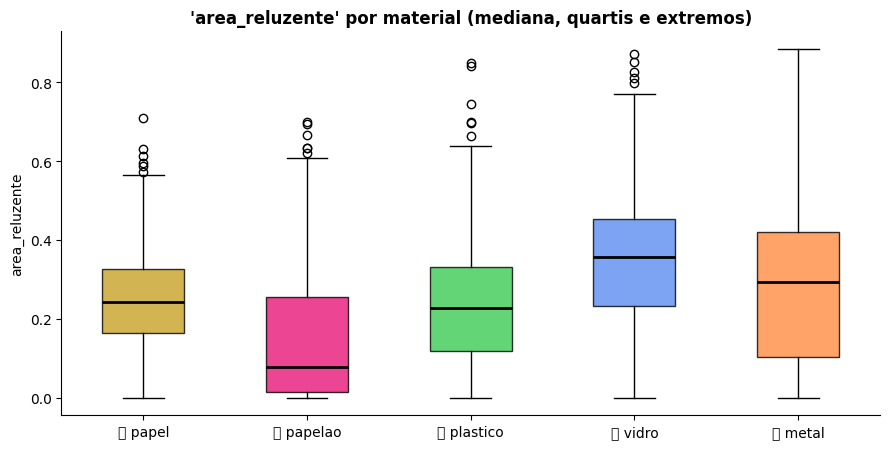

Média de 'area_reluzente':
   📄 papel     0.249
   📦 papelao   0.152
   🧴 plastico  0.229
   🍾 vidro     0.333
   🥫 metal     0.288

Amplitude entre classes: 0.182
   Observem também a SOBREPOSIÇÃO entre as distribuições: classes com médias
   distantes mas grande dispersão continuam difíceis de separar por essa
   variável isoladamente. Nenhum descritor precisa separar tudo sozinho.

SUGESTÃO: use a Dispersão para cruzar dois descritores e procurar pares que
   separem classes que um descritor sozinho não separa.


In [ ]:
#@title 📊 Investigue os descritores: escolha a variável E o tipo de gráfico { display-mode: "form" }
#@markdown Escolha o descritor e o gráfico, depois rode a célula (▶).
caracteristica = "area_reluzente"  #@param ["vermelho_medio", "verde_medio", "azul_medio", "vermelho_variacao", "verde_variacao", "azul_variacao", "brilho_medio", "contraste", "brilho_alto", "amplitude_luz", "bordas", "saturacao_media", "saturacao_variacao", "area_reluzente"]
tipo_de_grafico = "Boxplot"  #@param ["Boxplot", "Histograma sobreposto", "Violino", "Barras de media", "Dispersao contra outro descritor", "Galeria por faixa do descritor"]
segundo_descritor = "brilho_medio"  #@param ["vermelho_medio", "verde_medio", "azul_medio", "brilho_medio", "contraste", "bordas", "saturacao_media", "area_reluzente", "amplitude_luz"]

CORES_G = ["#C9A227", "#E6177A", "#3DCB55", "#5B8DEF", "#FF8C42"]
grupos = [X_caract[rotulos == c][caracteristica] for c in CLASSES]
rot_leg = [f"{EMOJI[c]} {c}" for c in CLASSES]

fig, ax = plt.subplots(figsize=(9, 4.6))

if tipo_de_grafico == "Boxplot":
    bp = ax.boxplot(grupos, patch_artist=True, tick_labels=rot_leg,
                    medianprops=dict(color="black", linewidth=2))
    for p, c in zip(bp["boxes"], CORES_G): p.set_facecolor(c); p.set_alpha(.8)
    ax.set_ylabel(caracteristica)
    ax.set_title(f"'{caracteristica}' por material (mediana, quartis e extremos)", fontweight="bold")

elif tipo_de_grafico == "Histograma sobreposto":
    bins = np.histogram_bin_edges(X_caract[caracteristica], bins=28)
    for g, c, r in zip(grupos, CORES_G, CLASSES):
        ax.hist(g, bins=bins, alpha=.55, label=r, color=c, edgecolor="white")
    ax.legend(); ax.set_xlabel(caracteristica); ax.set_ylabel("quantidade")
    ax.set_title(f"Distribuição de '{caracteristica}' por material", fontweight="bold")

elif tipo_de_grafico == "Violino":
    vp = ax.violinplot(grupos, showmedians=True)
    for corpo, c in zip(vp["bodies"], CORES_G): corpo.set_facecolor(c); corpo.set_alpha(.75)
    ax.set_xticks(range(1, len(CLASSES) + 1)); ax.set_xticklabels(rot_leg)
    ax.set_ylabel(caracteristica)
    ax.set_title(f"Densidade de '{caracteristica}' por material", fontweight="bold")

elif tipo_de_grafico == "Barras de media":
    med = [g.mean() for g in grupos]; err = [g.std()/np.sqrt(len(g)) for g in grupos]
    ax.bar(rot_leg, med, yerr=err, capsize=7, color=CORES_G, edgecolor="#1F2A44")
    ax.set_ylabel(f"média de {caracteristica}")
    ax.set_title(f"Média de '{caracteristica}' por material (barra = erro padrão)", fontweight="bold")

elif tipo_de_grafico == "Dispersao contra outro descritor":
    for c, cor in zip(CLASSES, CORES_G):
        sub = X_caract[rotulos == c]
        ax.scatter(sub[caracteristica], sub[segundo_descritor], s=16, alpha=.6,
                   color=cor, label=c, edgecolors="none")
    ax.set_xlabel(caracteristica); ax.set_ylabel(segundo_descritor); ax.legend()
    ax.set_title(f"'{caracteristica}' contra '{segundo_descritor}'", fontweight="bold")

else:  # Galeria por faixa
    plt.close(fig)
    ordem = np.argsort(X_caract[caracteristica].values)
    baixos, altos = ordem[:5], ordem[-5:]
    fig, axes = plt.subplots(2, 5, figsize=(11.5, 5))
    for linha, grupo in ((0, baixos), (1, altos)):
        for ax_, i in zip(axes[linha], grupo):
            ax_.imshow(fotos[i]); ax_.axis("off")
            ax_.set_title(f"{rotulos[i]}\n{X_caract[caracteristica].iloc[i]:.3f}", fontsize=8)
    fig.suptitle(f"Imagens com os MENORES (acima) e MAIORES (abaixo) valores de "
                 f"'{caracteristica}'", fontweight="bold")
    plt.tight_layout(); plt.show()
    print("Esta visualização conecta o número à imagem: vejam o que de fato muda")
    print(f"na aparência do material entre os extremos de '{caracteristica}'.")
    print("É a forma mais direta de verificar se um descritor mede o que vocês supõem.")

if tipo_de_grafico != "Galeria por faixa do descritor":
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.show()
    m = pd.Series({c: X_caract[rotulos == c][caracteristica].mean() for c in CLASSES})
    print(f"Média de '{caracteristica}':")
    for c in CLASSES: print(f"   {EMOJI[c]} {c:<9} {m[c]:.3f}")
    print(f"\nAmplitude entre classes: {m.max()-m.min():.3f}")
    print("   Observem também a SOBREPOSIÇÃO entre as distribuições: classes com médias")
    print("   distantes mas grande dispersão continuam difíceis de separar por essa")
    print("   variável isoladamente. Nenhum descritor precisa separar tudo sozinho.")
    print("\nSUGESTÃO: use a Dispersão para cruzar dois descritores e procurar pares que")
    print("   separem classes que um descritor sozinho não separa.")

> **Rosa:** *"A reflexão especular do metal aparece nos números de vocês. Era o que eu
> esperava. O difícil vai ser o vidro."*

<img src="https://lh3.googleusercontent.com/d/1SEXPNOB_d56gI0Ixd3ws5l0x5x-RhLRf=w1600" width="100%"
     alt="Cena dividida ao meio: à esquerda, uma lata de alumínio amassada sobre a esteira; à direita, a mesma lata redesenhada como uma grade luminosa de números, dígitos binários e histogramas. Feixes de luz ciano ligam os dois lados.">


---
# ⚙️ BLOCO 2 · CONFIGURAR
## *As decisões que definem o desempenho*

### Como os dados estão organizados

| Conjunto | Tamanho | Vocês têm os rótulos? | Para que serve |
|:---|:---|:---|:---|
| **Público** | 2.150 imagens | Sim | Treinar o modelo e validar as escolhas |
| **Teste** | **240 (fixo)** | Não | Comparação oficial entre todas as equipes |

O controle abaixo define que fatia do conjunto público fica reservada para **validação**.
O conjunto de teste tem tamanho fixo e igual para todas as equipes, e a submissão precisa
ter exatamente 240 linhas.


In [ ]:
#@title 🎛️ Parâmetros do experimento { display-mode: "form" }
#@markdown Ajuste os controles e rode a célula (▶) para registrar a configuração.

tamanho_da_validacao = 10  #@param {type:"slider", min:10, max:40, step:5}
conjunto_de_caracteristicas = "todas"  #@param ["todas", "so cor", "so brilho e textura"]
modelo_escolhido = "SVM"  #@param ["Regressao Logistica", "Floresta Aleatoria", "SVM"]
padronizar = True  #@param {type:"boolean"}
forca_C = 19.14  #@param {type:"slider", min:0.01, max:20, step:0.01}

GRUPOS = {
    "todas": list(X_caract.columns),
    "so cor": ["vermelho_medio","verde_medio","azul_medio","saturacao_media",
               "saturacao_variacao","vermelho_variacao","verde_variacao","azul_variacao"],
    "so brilho e textura": ["brilho_medio","contraste","brilho_alto","amplitude_luz",
                            "bordas","area_reluzente"]
}
colunas = GRUPOS[conjunto_de_caracteristicas]

print("PARÂMETROS DEFINIDOS")
print(f"   Validação .......... {tamanho_da_validacao}% do conjunto público")
print(f"   Descritores ........ {conjunto_de_caracteristicas} ({len(colunas)} variáveis)")
print(f"   Modelo ............. {modelo_escolhido}")
print(f"   Padronizar ......... {'sim' if padronizar else 'não'}")
print(f"   Força C ............ {forca_C}")
print(f"   Teste .............. {len(fotos_teste)} imagens  [FIXO para todas as equipes]")
print("\nConfiguração registrada. Ela será usada nas próximas células.")

PARÂMETROS DEFINIDOS
   Validação .......... 10% do conjunto público
   Descritores ........ todas (14 variáveis)
   Modelo ............. SVM
   Padronizar ......... sim
   Força C ............ 19.14
   Teste .............. 240 imagens  [FIXO para todas as equipes]

Configuração registrada. Ela será usada nas próximas células.


### Seleção de descritores e padronização

**Seleção de características.** Fornecer todos os descritores nem sempre maximiza o
desempenho. Variáveis com baixo poder discriminante adicionam ruído ao espaço de entrada.
Restringir o conjunto é uma forma de regularização.

**Padronização.** Os descritores têm escalas distintas. Modelos que operam sobre
distâncias, como o SVM, ou que dependem de otimização por gradiente, como a regressão
logística, são sensíveis a essa disparidade: variáveis de maior amplitude dominam a função
objetivo independentemente de sua relevância. Modelos baseados em árvores são invariantes a
transformações monotônicas e não se beneficiam disso.

---

### 📗 Referência técnica: nome exato e parâmetros de cada classe

**Vocês vão precisar desta tabela no Bloco 3.**

> **Por que isso importa.** No Bloco 3, apenas alguns parâmetros aparecem preenchidos.
> Todos os demais assumem silenciosamente o valor padrão. Completar só o nome da classe
> produz um resultado correto e mediano. Estudar esta tabela e **acrescentar parâmetros
> à chamada** produz resultados consistentemente melhores. A diferença é intencional.

#### 🔧 Padronizador

```python
from sklearn.preprocessing import StandardScaler
```

| Parâmetro | Padrão | O que faz |
|:---|:---|:---|
| `with_mean` | `True` | Subtrai a média de cada variável |
| `with_std` | `True` | Divide pelo desvio-padrão |
| `copy` | `True` | Se opera sobre uma cópia dos dados |

#### 📈 Regressão Logística

```python
from sklearn.linear_model import LogisticRegression
```

| Parâmetro | Padrão | O que faz |
|:---|:---|:---|
| `penalty` | `'l2'` | Tipo de regularização. Aceita `'l1'`, `'l2'`, `'elasticnet'`, `None` |
| `C` | `1.0` | Inverso da força da regularização. **Menor regulariza mais** |
| `solver` | `'lbfgs'` | Algoritmo de otimização |
| `max_iter` | `100` | Iterações máximas. Frequentemente insuficiente |
| `class_weight` | `None` | `'balanced'` compensa desbalanceamento |
| `multi_class` | automático | Estratégia para mais de duas classes |
| `random_state` | `None` | Semente |

#### 🌲 Floresta Aleatória

```python
from sklearn.ensemble import RandomForestClassifier
```

| Parâmetro | Padrão | O que faz |
|:---|:---|:---|
| `n_estimators` | `100` | Número de árvores |
| `max_depth` | `None` | Profundidade máxima |
| `min_samples_leaf` | `1` | Mínimo de amostras por folha. Aumentar suaviza |
| `max_features` | `'sqrt'` | Variáveis sorteadas por corte. Aceita fração |
| `class_weight` | `None` | `'balanced'` ou `'balanced_subsample'` |
| `criterion` | `'gini'` | Alternativa: `'entropy'` |
| `n_jobs` | `None` | `-1` usa todos os núcleos |
| `random_state` | `None` | Semente |

#### 🎯 SVM

```python
from sklearn.svm import SVC
```

| Parâmetro | Padrão | O que faz |
|:---|:---|:---|
| `C` | `1.0` | Penalidade por erro. **Maior ajusta mais aos dados de treino** |
| `kernel` | `'rbf'` | Aceita `'linear'`, `'poly'`, `'rbf'`, `'sigmoid'` |
| `gamma` | `'scale'` | Alcance de influência de cada exemplo. Aceita `'auto'` ou número |
| `degree` | `3` | Grau, quando `kernel='poly'` |
| `class_weight` | `None` | `'balanced'` compensa desbalanceamento |
| `probability` | `False` | Habilita `predict_proba`, ao custo de tempo |
| `random_state` | `None` | Semente |

> 💡 No SVM, **`C` e `gamma` interagem**. Aumentar `C` sem controlar `gamma` costuma levar
> a sobreajuste. Vale testar combinações e comparar na validação.


---
# ✏️ BLOCO 3 · MODELAR
## *Aqui vocês escrevem código*

A interface é a mesma do desafio anterior: `.fit()` para ajustar, `.predict()` para inferir.
Isso decorre da decisão de representação do Bloco 1: ao converter imagens em vetores de
características, o problema passou a ser tabular.

**Sobre o `Pipeline`.** Quando a padronização está ativa, o objeto `modelo` encapsula duas
etapas: o padronizador e o classificador. Ao chamar `.fit()`, o padronizador calcula média
e desvio **apenas com os dados de treino** e repassa o resultado ao classificador. Ao
chamar `.predict()`, aplica a mesma transformação sem recalcular. Essa disciplina evita que
informação da validação influencie o ajuste.

**Sobre a estrutura condicional.** O trecho abaixo escolhe um entre três modelos conforme
a opção marcada no Bloco 2, usando uma cadeia `if` / `elif` / `else`. `else` não recebe
condição, apenas os dois-pontos.

> ⚠️ A célula não executa enquanto houver lacunas. Preencham primeiro, executem depois.


In [ ]:
# ✏️ SUA VEZ · Parte 1: separar os dados e construir o modelo

X = X_caract[colunas]
y = rotulos

X_treino, X_valida, y_treino, y_valida = train_test_split(
    X, y,
    test_size=tamanho_da_validacao/100,
    random_state=42,
    stratify=y
)

if modelo_escolhido == "Regressao Logistica":
    nucleo = LogisticRegression(
        C=forca_C,
        max_iter=3000,
        random_state=42
    )

elif modelo_escolhido == "Floresta Aleatoria":
    nucleo = RandomForestClassifier(
        n_estimators=250,
        random_state=42,
        n_jobs=-1
    )

else:
    nucleo = SVC(
        C=forca_C,
        kernel="rbf",
        gamma="scale",
        random_state=42
    )

modelo = make_pipeline(StandardScaler(), nucleo) if padronizar else nucleo

print(f"Treino:    {len(X_treino)} imagens")
print(f"Validação: {len(X_valida)} imagens")
print(f"Modelo construído: {type(nucleo).__name__}"
      f"{' dentro de um Pipeline com StandardScaler' if padronizar else ''}")

Treino:    1935 imagens
Validação: 215 imagens
Modelo construído: SVC dentro de um Pipeline com StandardScaler


In [ ]:
# ✏️ SUA VEZ · Parte 2: treinar e prever

# LACUNA 8 ▸ treinar o modelo
modelo.fit(X_treino, y_treino)

# LACUNA 9 ▸ fazer previsões na validação
previsoes = modelo.predict(X_valida)

print(f"Modelo ajustado. {len(previsoes)} previsões geradas para a validação.")

Modelo ajustado. 215 previsões geradas para a validação.


In [ ]:
#@title 🔎 Verificação das lacunas { display-mode: "form" }
erros = []
try:
    _, cnt_t = np.unique(y_treino, return_counts=True)
    _, cnt_a = np.unique(y, return_counts=True)
    if np.abs(cnt_t/len(y_treino) - cnt_a/len(y)).max() > 0.04:
        erros.append("LACUNA 1: as proporções das classes no treino diferem do conjunto "
                     "completo. O argumento 'stratify' não recebeu o vetor correto.")
except NameError:
    erros.append("LACUNA 1: X_treino/y_treino não existem. Rode a Parte 1.")
try:
    esperado = {"Regressao Logistica": "LogisticRegression",
                "Floresta Aleatoria": "RandomForestClassifier",
                "SVM": "SVC"}[modelo_escolhido]
    if type(nucleo).__name__ != esperado:
        erros.append(f"LACUNAS 2 a 6: para '{modelo_escolhido}' era esperada a classe "
                     f"{esperado}, mas foi construída {type(nucleo).__name__}.")
except NameError:
    erros.append("LACUNAS 2 a 6: a variável 'nucleo' não existe.")
try:
    if padronizar:
        nomes = [type(p).__name__ for _, p in modelo.steps]
        if "StandardScaler" not in nomes:
            erros.append("LACUNA 7: a padronização está ligada, mas o Pipeline não contém "
                         "um StandardScaler.")
except (NameError, AttributeError):
    if padronizar: erros.append("LACUNA 7: o Pipeline não foi construído corretamente.")
try:
    treinado = hasattr(modelo, "classes_") or (hasattr(modelo, "steps") and
               hasattr(modelo.steps[-1][1], "classes_"))
    if not treinado:
        erros.append("LACUNA 8: o modelo não possui parâmetros ajustados.")
except NameError: pass
try:
    if len(previsoes) != len(X_valida):
        erros.append(f"LACUNA 9: {len(previsoes)} previsões para {len(X_valida)} casos.")
except NameError:
    erros.append("LACUNA 9: a variável 'previsoes' não existe.")

if erros:
    print("VERIFICAÇÃO REPROVADA. Pontos a revisar:\n")
    for e in erros: print("   [!] " + e + "\n")
else:
    print("VERIFICAÇÃO APROVADA\n")
    print("   Pipeline completo: dados estratificados, modelo construído e ajustado.")
    pad = {k: v for k, v in nucleo.get_params().items()
           if k in ("class_weight","min_samples_leaf","max_features","gamma","kernel",
                    "criterion","max_depth","degree")
           and v not in (None, 1, "sqrt", "scale", "rbf", "gini", 3)}
    if pad:
        print(f"\n   Parâmetros adicionais detectados na ZONA LIVRE: {pad}")
    else:
        print("\n   Nenhum parâmetro adicional foi declarado: o modelo usa os valores")
        print("   padrão. É válido, mas as tabelas do Bloco 2 dão margem real de melhoria.")

VERIFICAÇÃO APROVADA

   Pipeline completo: dados estratificados, modelo construído e ajustado.

   Nenhum parâmetro adicional foi declarado: o modelo usa os valores
   padrão. É válido, mas as tabelas do Bloco 2 dão margem real de melhoria.


---
# 📈 BLOCO 4 · AVALIAR
## *Onde a máquina se confunde?*

> **Rosa:** *"O número agregado me diz pouco. Preciso saber quais pares de material ele
> confunde. Vidro classificado como plástico vai para a prensa e danifica o equipamento.
> Papel classificado como papelão só reduz um pouco o preço do lote."*

A observação identifica com precisão o limite de qualquer métrica escalar: ela agrega erros
de naturezas e custos distintos em um único número. A matriz de confusão preserva a
estrutura dos erros, e é ela que orienta decisões de engenharia.


           DESEMPENHO NO CONJUNTO DE VALIDAÇÃO
  Acurácia (acertos no geral) ..........  77.2%
  ⭐ F1-MACRO (métrica oficial) .........  76.6%
  Desempenho alto. Verifiquem a estabilidade entre execuções.


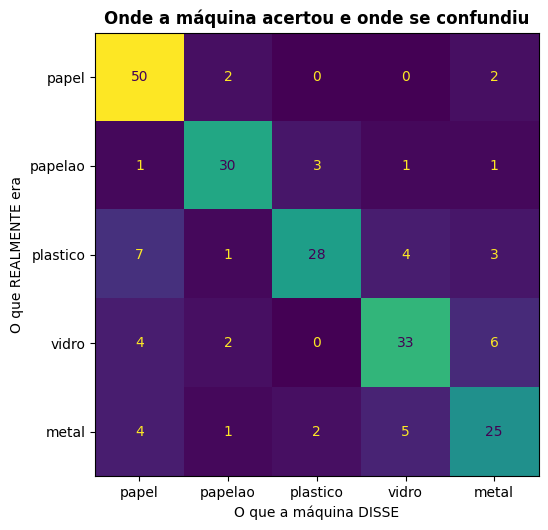


🔎 MAIORES CONFUSÕES DO MODELO:
   • 7 fotos de 🧴 PLASTICO foram chamadas de 📄 PAPEL
   • 6 fotos de 🍾 VIDRO foram chamadas de 🥫 METAL
   • 5 fotos de 🥫 METAL foram chamadas de 🍾 VIDRO

   Analisem: quais descritores esses dois materiais compartilham, e que
   medida adicional permitiria separá-los?

              precision    recall  f1-score   support

       metal      0.676     0.676     0.676        37
       papel      0.758     0.926     0.833        54
     papelao      0.833     0.833     0.833        36
    plastico      0.848     0.651     0.737        43
       vidro      0.767     0.733     0.750        45

    accuracy                          0.772       215
   macro avg      0.777     0.764     0.766       215
weighted avg      0.776     0.772     0.769       215



In [ ]:
#@title 🏆 O resultado da triagem automática { display-mode: "form" }
acuracia = accuracy_score(y_valida, previsoes)
f1 = f1_score(y_valida, previsoes, average="macro")

print("="*60)
print("           DESEMPENHO NO CONJUNTO DE VALIDAÇÃO")
print("="*60)
print(f"  Acurácia (acertos no geral) .......... {acuracia*100:5.1f}%")
print(f"  ⭐ F1-MACRO (métrica oficial) ......... {f1*100:5.1f}%")
print("="*60)
# Faixas calibradas nestes descritores: ~72% e o teto observado com boa configuração.
if   f1 >= .70: print("  Desempenho alto. Verifiquem a estabilidade entre execuções.")
elif f1 >= .64: print("  Desempenho sólido, com margem de otimização no Bloco 2.")
elif f1 >= .55: print("  Desempenho intermediário. Revisem o conjunto de características.")
else:           print("  Desempenho baixo. A representação atual não separa as classes.")

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ConfusionMatrixDisplay(confusion_matrix(y_valida, previsoes, labels=CLASSES),
    display_labels=CLASSES).plot(ax=ax, cmap="viridis", colorbar=False)
ax.set_title("Onde a máquina acertou e onde se confundiu", fontweight="bold")
ax.set_xlabel("O que a máquina DISSE"); ax.set_ylabel("O que REALMENTE era")
plt.tight_layout(); plt.show()

cm = confusion_matrix(y_valida, previsoes, labels=CLASSES)
n = len(CLASSES)
confusoes = [(CLASSES[i], CLASSES[j], cm[i, j])
             for i in range(n) for j in range(n) if i != j and cm[i, j] > 0]
confusoes.sort(key=lambda t: -t[2])
print("\n🔎 MAIORES CONFUSÕES DO MODELO:")
if confusoes:
    for real, previsto, q in confusoes[:3]:
        print(f"   • {q} fotos de {EMOJI[real]} {real.upper()} "
              f"foram chamadas de {EMOJI[previsto]} {previsto.upper()}")
    print("\n   Analisem: quais descritores esses dois materiais compartilham, e que")
    print("   medida adicional permitiria separá-los?")
else:
    print("   Nenhuma! O modelo acertou todas as fotos do teste. 🎯")
print()
print(classification_report(y_valida, previsoes, digits=3))

if not padronizar and modelo_escolhido in ("Regressao Logistica", "SVM"):
    print("[!] O modelo escolhido é sensível à escala dos descritores e a")
    print("    padronização está DESLIGADA. Ligá-la no Bloco 2 costuma ser o")
    print("    ganho isolado mais relevante nesta trilha.")

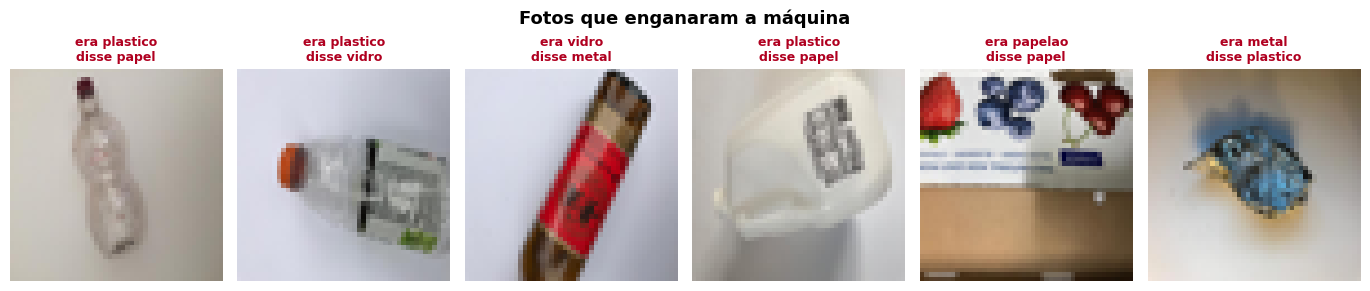

Classificações incorretas: 49 de 215 imagens.

A análise qualitativa de erros é prática padrão em visão computacional.
Examinem os casos acima e determinem:
   Um anotador humano classificaria essas imagens corretamente? Se não, o
   limite é da representação ou da própria qualidade do rótulo?
   Os erros compartilham alguma condição (baixa luminância, reflexo atípico)?
   Que descritor adicional capturaria a diferença que os atuais não capturam?


In [ ]:
#@title 🕵️ A galeria dos erros { display-mode: "form" }
# A parte mais reveladora do desafio: **olhar as fotos que o modelo errou.**
idx_teste = X_valida.index.to_numpy()
y_valida_arr = np.asarray(y_valida)
errou = np.where(previsoes != y_valida_arr)[0]

if len(errou) == 0:
    print("🎯 Seu modelo não errou nenhuma foto do teste! Impressionante.")
else:
    n = min(6, len(errou))
    fig, axes = plt.subplots(1, n, figsize=(2.3*n, 3.1))
    if n == 1: axes = [axes]
    for ax, k in zip(axes, errou[:n]):
        ax.imshow(fotos[idx_teste[k]]); ax.axis("off")
        ax.set_title(f"era {y_valida_arr[k]}\ndisse {previsoes[k]}",
                     fontsize=9, color="#B00020", fontweight="bold")
    fig.suptitle("Fotos que enganaram a máquina", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()
    print(f"Classificações incorretas: {len(errou)} de {len(y_valida)} imagens.\n")
    print("A análise qualitativa de erros é prática padrão em visão computacional.")
    print("Examinem os casos acima e determinem:")
    print("   Um anotador humano classificaria essas imagens corretamente? Se não, o")
    print("   limite é da representação ou da própria qualidade do rótulo?")
    print("   Os erros compartilham alguma condição (baixa luminância, reflexo atípico)?")
    print("   Que descritor adicional capturaria a diferença que os atuais não capturam?")

---
# 🤔 PARADA OBRIGATÓRIA: uma conversa com a Dona Rosa

> **Rosa:** *"Tenho duas questões, e nenhuma delas é sobre o código de vocês."*
>
> *"A primeira é de governança. A cooperativa é autogestionária: as decisões passam por
> assembleia. Se eu levar uma ferramenta que altera o processo de trabalho, a assembleia
> vai perguntar quem decidiu implantá-la e sob quais condições. Sistemas assim costumam
> chegar prontos, decididos por quem não trabalha neles."*
>
> *"A segunda é econômica. Automação em triagem historicamente foi usada para reduzir
> postos, não para aliviar carga. A tecnologia não determina esse resultado, mas também não
> impede. Determina quem controla a implantação."*

### Questões para a equipe deliberar

1. **Deslocamento de domínio.** As imagens foram capturadas em um galpão específico, com
   iluminação e câmera específicas. Um modelo ajustado sobre esses descritores aprende, em
   parte, as condições da captura. Aplicado em outra cooperativa, com outra iluminação, o
   desempenho tende a cair mesmo com os mesmos materiais. Isso se chama **deslocamento de
   domínio** (*domain shift*) e é uma das principais causas de falha de sistemas de IA em
   produção. Como vocês testariam a exposição do modelo de vocês a esse risco, e o que
   fariam para mitigá-la?

2. **Autonomia da decisão.** Um sistema pode operar em modo autônomo, decidindo sozinho, ou
   em modo assistivo, sinalizando para decisão humana. Dada a taxa de erro que vocês
   mediram e o custo dos erros específicos que identificaram na matriz de confusão, qual
   dos dois regimes vocês recomendariam, e a partir de que desempenho a recomendação
   mudaria?

3. **Quem decide sobre a implantação.** A Rosa levanta uma questão que a literatura de
   tecnologia e trabalho trata há décadas: os efeitos da automação sobre o emprego dependem
   menos da técnica e mais de quem controla as decisões de implantação. Em uma cooperativa
   autogestionária, isso é decidido em assembleia. Que informação vocês precisariam entregar
   para que essa assembleia decidisse com autonomia real, e não apenas homologasse uma
   decisão técnica já tomada?

<img src="https://lh3.googleusercontent.com/d/11via5b3WO3iPrDtLkmXPWTynuAeHXGwt=w1600" width="100%"
     alt="Dois catadores trabalham na esteira ao lado de um braço robótico e de uma câmera com feixe ciano. No painel acima, ícones de lata, garrafa e papelão aparecem marcados como separados corretamente. Luz dourada de fim de tarde entra pela janela.">


In [ ]:
#@title 📝 O relatório da sua equipe para a Dona Rosa { display-mode: "form" }
#@markdown Este texto vale nota e pode decidir o desempate.
nome_da_equipe = "Athēná"  #@param {type:"string"}
#@markdown **1. Quais características vocês usaram e por quê?**
resposta_1 = "Usamos todas as 14 características disponíveis, envolvendo cor, brilho, contraste, saturação, bordas e área reluzente. Escolhemos todas porque cada material pode apresentar diferenças nessas características e queríamos fornecer o máximo de informações possíveis para o modelo conseguir diferenciar os materiais."  #@param {type:"string"}
#@markdown **2. Quais materiais o modelo mais confundiu? Por que vocês acham que isso acontece?**
resposta_2 = "Os materiais que mais confundiram foram principalmente plástico com papel, plástico com vidro e papelão com papel. Isso acontece porque alguns desses materiais podem ter cores, brilho e aparência muito parecidos. Além disso, reflexos e iluminação podem fazer um material parecer outro. Os descritores usados também não conseguem representar tão bem o formato e a textura dos objetos."  #@param {type:"string"}
#@markdown **3. Regime de operação recomendado (autônomo ou assistivo) e justificativa.**
resposta_3 = "Recomendamos a supervisão, pois o modelo acertou cerca de 76% das classificações, mas ainda apresentou alguns erros. Assim, ele pode ajudar na identificação dos materiais, enquanto uma pessoa supervisiona e confere os casos em que o modelo pode estar errado."  #@param {type:"string"}

relatorio = {"equipe": nome_da_equipe, "modelo": modelo_escolhido,
             "caracteristicas": conjunto_de_caracteristicas, "padronizar": padronizar,
             "C": forca_C, "teste_pct": tamanho_da_validacao,
             "f1_macro": round(f1, 4), "acuracia": round(acuracia, 4),
             "just_caracteristicas": resposta_1, "just_confusoes": resposta_2,
             "just_impacto": resposta_3}
faltando = [k for k in ["equipe", "just_caracteristicas", "just_confusoes", "just_impacto"]
            if not relatorio[k].strip()]
if faltando:
    print("⚠️ Ainda faltam campos:", ", ".join(faltando))
else:
    print("Relatório completo. Prossigam para a submissão.")

Relatório completo. Prossigam para a submissão.


In [ ]:
#@title 🚀 Gerar o arquivo de submissão { display-mode: "form" }
#@markdown Rode a célula (▶). Os dois arquivos são baixados automaticamente.
import json, pathlib

PASTA_SUBMISSAO = pathlib.Path("submissoes/visao")
PASTA_SUBMISSAO.mkdir(parents=True, exist_ok=True)
if "relatorio" not in dir() or not isinstance(relatorio, dict):
    relatorio = {"equipe": "", "modelo": modelo_escolhido,
                 "caracteristicas": conjunto_de_caracteristicas, "padronizar": padronizar,
                 "C": forca_C, "teste_pct": tamanho_da_validacao,
                 "f1_macro": round(f1, 4), "acuracia": round(acuracia, 4),
                 "just_caracteristicas": "", "just_confusoes": "", "just_impacto": ""}

X_final = X_caract_teste[colunas]
palpites = modelo.predict(X_final)
submissao = pd.DataFrame({"id_foto": np.arange(len(palpites)),
                          "material_previsto": palpites})

assert len(submissao) == N_TESTE, f"A submissão precisa ter {N_TESTE} linhas."
csv_saida = PASTA_SUBMISSAO / "submissao_visao.csv"
json_saida = PASTA_SUBMISSAO / "relatorio_visao.json"
submissao.to_csv(csv_saida, index=False)
with open(json_saida, "w", encoding="utf-8") as f:
    json.dump(relatorio, f, ensure_ascii=False, indent=2)

print("="*60)
print("             ARQUIVOS PRONTOS PARA ENVIO")
print("="*60)
print(f"  submissao_visao.csv   ({len(submissao)} linhas)")
print("  relatorio_visao.json")
print("="*60)
print("\n  Distribuição prevista no teste:")
for k, v in pd.Series(palpites).value_counts().items():
    print(f"     {EMOJI[k]} {k:<10} {v:>4}")

try:
    from google.colab import files
    files.download(str(csv_saida))
    files.download(str(json_saida))
    print("\n  Download iniciado. Enviem os dois arquivos na plataforma.")
except ImportError:
    print(f"\n  Fora do Colab: os arquivos estão em {PASTA_SUBMISSAO.resolve()}")

             ARQUIVOS PRONTOS PARA ENVIO
  submissao_visao.csv   (240 linhas)
  relatorio_visao.json

  Distribuição prevista no teste:
     📄 papel        63
     🍾 vidro        53
     🧴 plastico     42
     📦 papelao      42
     🥫 metal        40


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  Download iniciado. Enviem os dois arquivos na plataforma.


In [ ]:
# ============================================================
# 🔥 BUSCA FINAL SVM
#
# Objetivo: superar F1-macro = 0.765837
#
# FIXO:
#   - Validação = 10%
#   - Todas as 14 características
#   - StandardScaler
#   - Kernel RBF
#
# VARIÁVEIS:
#   - C = 15.00 até 20.00, passo 0.01
#   - Gamma = vários valores
#   - class_weight = None / balanced
# ============================================================

import time
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score


# ============================================================
# CONFIGURAÇÃO
# ============================================================

SEED = 42
TEST_SIZE = 0.10

# ------------------------------------------------------------
# C
# ------------------------------------------------------------

C_VALORES = np.round(
    np.arange(15.00, 20.001, 0.01),
    2
)

# ------------------------------------------------------------
# GAMMA
# ------------------------------------------------------------

GAMMA_VALORES = [
    "scale",

    0.0005,
    0.001,
    0.002,
    0.003,
    0.005,
    0.007,

    0.01,
    0.015,
    0.02,
    0.03,
    0.04,
    0.05,
    0.07,

    0.10,
    0.15,
    0.20,
    0.30,
    0.50
]

# ------------------------------------------------------------
# PESO DAS CLASSES
# ------------------------------------------------------------

CLASS_WEIGHTS = [
    None,
    "balanced"
]

# ------------------------------------------------------------
# TODAS AS FEATURES
# ------------------------------------------------------------

CARACTERISTICAS = [
    "vermelho_medio",
    "verde_medio",
    "azul_medio",
    "vermelho_variacao",
    "verde_variacao",
    "azul_variacao",
    "brilho_medio",
    "contraste",
    "brilho_alto",
    "amplitude_luz",
    "bordas",
    "saturacao_media",
    "saturacao_variacao",
    "area_reluzente"
]

X = X_caract[CARACTERISTICAS]
y = rotulos


# ============================================================
# RESUMO
# ============================================================

N_CONFIG = (
    len(C_VALORES)
    * len(GAMMA_VALORES)
    * len(CLASS_WEIGHTS)
)

print("=" * 75)
print("🔥 BUSCA FINAL SVM")
print("=" * 75)

print(f"Validação:       {TEST_SIZE * 100:.0f}%")
print(f"Características: todas ({len(CARACTERISTICAS)})")
print("Padronização:    StandardScaler")
print("Kernel:          RBF")
print(f"C:               {C_VALORES[0]:.2f} até {C_VALORES[-1]:.2f}")
print(f"Passo C:         0.01")
print(f"Gamma:           {len(GAMMA_VALORES)} valores")
print(f"Class weights:   {CLASS_WEIGHTS}")
print(f"\nTotal:           {N_CONFIG:,} configurações")

print("\n🏆 Referência atual:")
print("C = 19.14")
print('gamma = "scale"')
print("class_weight = None")
print("F1-macro = 0.765837")


# ============================================================
# DIVISÃO FIXA
# ============================================================

idx = np.arange(len(X))

idx_treino, idx_valida = train_test_split(
    idx,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)

X_treino = X.iloc[idx_treino]
X_valida = X.iloc[idx_valida]

y_treino = y[idx_treino]
y_valida = y[idx_valida]


# ============================================================
# BUSCA
# ============================================================

resultados = []

inicio_total = time.time()

melhor_f1 = -1
melhor_config = None

contador = 0


for class_weight in CLASS_WEIGHTS:

    print("\n" + "=" * 75)
    print(f"CLASS_WEIGHT = {class_weight}")
    print("=" * 75)

    for gamma in GAMMA_VALORES:

        for C in C_VALORES:

            contador += 1

            inicio = time.time()

            modelo = Pipeline([
                ("scaler", StandardScaler()),

                ("svm", SVC(
                    kernel="rbf",
                    C=float(C),
                    gamma=gamma,
                    class_weight=class_weight,
                    random_state=42
                ))
            ])

            modelo.fit(
                X_treino,
                y_treino
            )

            previsoes = modelo.predict(
                X_valida
            )

            f1 = f1_score(
                y_valida,
                previsoes,
                average="macro"
            )

            acc = accuracy_score(
                y_valida,
                previsoes
            )

            tempo = time.time() - inicio

            resultados.append({
                "validacao": TEST_SIZE,
                "modelo": "SVM",
                "caracteristicas": "todas",
                "padronizar": True,
                "kernel": "rbf",
                "C": float(C),
                "gamma": gamma,
                "class_weight": class_weight,
                "f1_macro": f1,
                "acuracia": acc,
                "tempo_segundos": tempo
            })


            # ------------------------------------------------
            # NOVO MELHOR
            # ------------------------------------------------

            if f1 > melhor_f1:

                melhor_f1 = f1

                melhor_config = {
                    "C": float(C),
                    "gamma": gamma,
                    "class_weight": class_weight,
                    "f1_macro": f1,
                    "acuracia": acc
                }

                print("\n🔥 NOVO RECORDE!")
                print(f"F1-macro:     {f1:.6f}")
                print(f"Acurácia:     {acc:.6f}")
                print(f"C:            {C:.2f}")
                print(f"Gamma:        {gamma}")
                print(f"Class weight: {class_weight}")


            # ------------------------------------------------
            # PROGRESSO
            # ------------------------------------------------

            if contador % 100 == 0:

                tempo_total = time.time() - inicio_total

                print(
                    f"[{contador:,}/{N_CONFIG:,}] "
                    f"Melhor F1={melhor_f1:.6f} | "
                    f"C={melhor_config['C']:.2f} | "
                    f"gamma={melhor_config['gamma']} | "
                    f"weight={melhor_config['class_weight']} | "
                    f"tempo={tempo_total/60:.1f} min"
                )


            # ------------------------------------------------
            # SALVAMENTO PARCIAL
            # ------------------------------------------------

            if contador % 250 == 0:

                df_parcial = pd.DataFrame(resultados)

                df_parcial = df_parcial.sort_values(
                    "f1_macro",
                    ascending=False
                )

                df_parcial.to_csv(
                    "resultado_busca_final_parcial.csv",
                    index=False
                )


# ============================================================
# RESULTADO FINAL
# ============================================================

df_final = pd.DataFrame(resultados)

df_final = df_final.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)


# ============================================================
# TOP 30
# ============================================================

print("\n\n" + "=" * 75)
print("🏆 TOP 30 CONFIGURAÇÕES")
print("=" * 75)

display(
    df_final.head(30)
)


# ============================================================
# CAMPEÃ
# ============================================================

melhor = df_final.iloc[0]

print("\n" + "=" * 75)
print("🏆🏆 MELHOR CONFIGURAÇÃO ENCONTRADA")
print("=" * 75)

print(f"Validação:       {melhor['validacao'] * 100:.0f}%")
print(f"Características: TODAS")
print(f"Padronização:    True")
print(f"Kernel:          RBF")
print(f"C:               {melhor['C']:.2f}")
print(f"Gamma:            {melhor['gamma']}")
print(f"Class weight:    {melhor['class_weight']}")
print(f"F1-macro:        {melhor['f1_macro']:.6f}")
print(f"Acurácia:        {melhor['acuracia']:.6f}")

print("\nComparação com o recorde anterior:")
print("Anterior:        0.765837")
print(f"Novo:            {melhor['f1_macro']:.6f}")
print(
    f"Diferença:       "
    f"{melhor['f1_macro'] - 0.765837:+.6f}"
)


# ============================================================
# MELHOR POR GAMMA
# ============================================================

print("\n" + "=" * 75)
print("MELHOR CONFIGURAÇÃO POR GAMMA")
print("=" * 75)

melhores_gamma = (
    df_final
    .sort_values("f1_macro", ascending=False)
    .groupby("gamma")
    .first()
    .reset_index()
)

display(
    melhores_gamma[
        [
            "gamma",
            "C",
            "class_weight",
            "f1_macro",
            "acuracia"
        ]
    ].sort_values(
        "f1_macro",
        ascending=False
    )
)


# ============================================================
# MELHOR POR CLASS_WEIGHT
# ============================================================

print("\n" + "=" * 75)
print("MELHOR POR CLASS_WEIGHT")
print("=" * 75)

melhores_weight = (
    df_final
    .sort_values("f1_macro", ascending=False)
    .groupby("class_weight")
    .first()
    .reset_index()
)

display(
    melhores_weight[
        [
            "class_weight",
            "C",
            "gamma",
            "f1_macro",
            "acuracia"
        ]
    ]
)


# ============================================================
# SALVAR RESULTADO COMPLETO
# ============================================================

df_final.to_csv(
    "resultado_busca_final_SVM.csv",
    index=False
)

print("\n💾 Arquivos salvos:")
print("   resultado_busca_final_SVM.csv")
print("   resultado_busca_final_parcial.csv")

print(
    f"\n⏱️ Tempo total: "
    f"{(time.time() - inicio_total) / 60:.2f} minutos"
)

🔥 BUSCA FINAL SVM
Validação:       10%
Características: todas (14)
Padronização:    StandardScaler
Kernel:          RBF
C:               15.00 até 20.00
Passo C:         0.01
Gamma:           19 valores
Class weights:   [None, 'balanced']

Total:           19,038 configurações

🏆 Referência atual:
C = 19.14
gamma = "scale"
class_weight = None
F1-macro = 0.765837

CLASS_WEIGHT = None

🔥 NOVO RECORDE!
F1-macro:     0.750027
Acurácia:     0.758140
C:            15.00
Gamma:        scale
Class weight: None

🔥 NOVO RECORDE!
F1-macro:     0.755378
Acurácia:     0.762791
C:            15.99
Gamma:        scale
Class weight: None
[100/19,038] Melhor F1=0.755378 | C=15.99 | gamma=scale | weight=None | tempo=0.4 min


---
# 🌟 FIM DA MISSÃO RECOMEÇO

> **Rosa:** *"Levamos a proposta de vocês à assembleia. Aprovamos em regime assistivo: a
> máquina sinaliza, a pessoa confirma. Foi a recomendação de vocês e foi também o que a
> assembleia entendeu como aceitável."*
>
> *"O primeiro lote saiu sem contaminação e recebemos o valor integral. Mas o que fez
> diferença na discussão não foi o número de acerto. Foi vocês terem descrito onde o modelo
> falha e sob quais condições ele deixa de valer. Isso permitiu decidir com informação."*

---

### Competências desenvolvidas neste desafio

- O problema da representação em dados não estruturados
- Extração de características e redução de dimensionalidade
- A separação entre representação e classificação como princípio de projeto
- O papel do conhecimento de domínio na engenharia de atributos
- Sensibilidade de algoritmos à escala das variáveis, e quando padronizar
- `Pipeline` como mecanismo de disciplina no ajuste de transformações
- Análise qualitativa de erros e leitura estrutural da matriz de confusão
- Deslocamento de domínio como causa de falha em produção
- Regimes de autonomia e governança de sistemas automatizados

**Otimização.** Alterem **um fator por vez** e registrem o efeito: conjunto de
características, algoritmo, padronização, valor de C. Comparações válidas exigem isolar a
variável manipulada.
